# SOTA Fraud Detection Model with XGBoost

Our weighted classifier achieved strong performance with high precision, recall, and F1 score. Upon some research, we found that XGBoost and GNN are some SOTA models known for being a strong fraud detector.

However, while Graph Neural Networks are a state-of-the-art approach for fraud detection when relational data is available, our dataset is purely tabular without explicit relationships between transactions. Hence, applying GNN in this case would require artificial graph construction, which may not reflect real-world connections.

Therefore this notebook, we have chosen to explore XGBoost, a state-of-the-art model for tabular data, and compare its performance against our previous models.

XGBoost is widely used in real-world fraud detection systems due to its ability to handle class imbalance, capture complex feature interactions, and provide strong predictive performance.

We will train an XGBoost model, perform threshold tuning, and evaluate it using the same metrics for fair comparison.

[XGBoost vs Random Forest vs GNN for Fraud Detection: Which Algorithm Wins?](https://kumo.ai/resources/learn/fraud-detection-xgboost-vs-gnn/)

[GADBench: Revisiting and Benchmarking Supervised Graph Anomaly Detection](https://arxiv.org/html/2306.12251v1)

## Imports

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from xgboost import XGBClassifier

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    precision_recall_curve,
    roc_curve
)

In [8]:
# Use GPU if available, else use CPU
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print(f"Using device: {device}")

Using device: cuda


# Data

In [9]:
df = pd.read_csv('./data/creditcard.csv')
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## Data Preprocessing

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

SEED = 42 # added for reproducibility
np.random.seed(SEED)
torch.manual_seed(SEED)

# Separate features and target
X = df.drop('Class', axis=1).copy()
y = df['Class'].astype(np.float32).values

# Train-test split (80-20)
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

# Further split training data into train and validation sets (75-25 of the 80%)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.25, random_state=SEED, stratify=y_train_full
)

# Feature engineering for skewed columns
for frame in (X_train, X_val, X_test):
    frame['Amount'] = np.log1p(frame['Amount'])
    frame['Time'] = np.log1p(frame['Time'])

# Normalize using train statistics only to prevent data leakage
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

# Convert to PyTorch tensors
X_train = torch.tensor(X_train, dtype=torch.float32)
X_val = torch.tensor(X_val, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)

y_train = torch.tensor(y_train, dtype=torch.float32)
y_val = torch.tensor(y_val, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32)



## Handle class imbalance

In [15]:
n_train = len(y_train)
n_normal = (y_train == 0).sum()
n_fraud = (y_train == 1).sum()

scale_pos_weight = float(n_normal / n_fraud)

print(f"Train samples: {n_train}")
print(f"Normal transactions: {n_normal}")
print(f"Fraudulent transactions: {n_fraud}")
print(f"Positive class weight: {scale_pos_weight:.4f}")

Train samples: 170883
Normal transactions: 170588
Fraudulent transactions: 295
Positive class weight: 578.2644


# Model

In [42]:
model = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    verbose=False
)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


# Evaluation & Testing


In [43]:
def evaluate(model, X, y, threshold=0.5):
    probs = model.predict_proba(X)[:, 1]
    preds = (probs >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(y, preds).ravel()

    return {
        "accuracy": accuracy_score(y, preds),
        "balanced_accuracy": balanced_accuracy_score(y, preds),
        "precision": precision_score(y, preds, zero_division=0),
        "recall": recall_score(y, preds, zero_division=0),
        "f1": f1_score(y, preds, zero_division=0),
        "roc_auc": roc_auc_score(y, probs),
        "pr_auc": average_precision_score(y, probs),
        "confusion_matrix": np.array([[tn, fp], [fn, tp]]),
        "probs": probs
    }

## Threshold tuning

In [44]:
thresholds = [0.5, 0.6, 0.7, 0.8, 0.9, 0.95, 0.99]

best_threshold = 0.5
best_f1 = -1

print("=" * 50)
print("VALIDATION THRESHOLD SEARCH")
print("=" * 50)

for thr in thresholds:
    metrics = evaluate(model, X_val, y_val, threshold=thr)
    print(
        f"Threshold: {thr:.2f} | "
        f"Precision: {metrics['precision']:.4f} | "
        f"Recall: {metrics['recall']:.4f} | "
        f"F1: {metrics['f1']:.4f}"
    )

    if metrics["f1"] > best_f1:
        best_f1 = metrics["f1"]
        best_threshold = thr

print(f"\nBest threshold: {best_threshold:.2f}")

VALIDATION THRESHOLD SEARCH
Threshold: 0.50 | Precision: 0.8556 | Recall: 0.7778 | F1: 0.8148
Threshold: 0.60 | Precision: 0.8953 | Recall: 0.7778 | F1: 0.8324
Threshold: 0.70 | Precision: 0.8953 | Recall: 0.7778 | F1: 0.8324
Threshold: 0.80 | Precision: 0.9167 | Recall: 0.7778 | F1: 0.8415
Threshold: 0.90 | Precision: 0.9277 | Recall: 0.7778 | F1: 0.8462
Threshold: 0.95 | Precision: 0.9500 | Recall: 0.7677 | F1: 0.8492
Threshold: 0.99 | Precision: 0.9467 | Recall: 0.7172 | F1: 0.8161

Best threshold: 0.95


## Final test valuation

In [45]:
test_metrics = evaluate(model, X_test, y_test, threshold=best_threshold)

print("=" * 50)
print("TEST SET RESULTS")
print("=" * 50)

for k in ["accuracy", "balanced_accuracy", "precision", "recall", "f1", "roc_auc", "pr_auc"]:
    print(f"{k}: {test_metrics[k]:.4f}")

tn, fp, fn, tp = test_metrics["confusion_matrix"].ravel()

print("\nConfusion Matrix:")
print(f"TN: {tn}, FP: {fp}, FN: {fn}, TP: {tp}")

TEST SET RESULTS
accuracy: 0.9995
balanced_accuracy: 0.8928
precision: 0.9390
recall: 0.7857
f1: 0.8556
roc_auc: 0.9771
pr_auc: 0.8697

Confusion Matrix:
TN: 56859, FP: 5, FN: 21, TP: 77


# Visualization

Confusion matrix

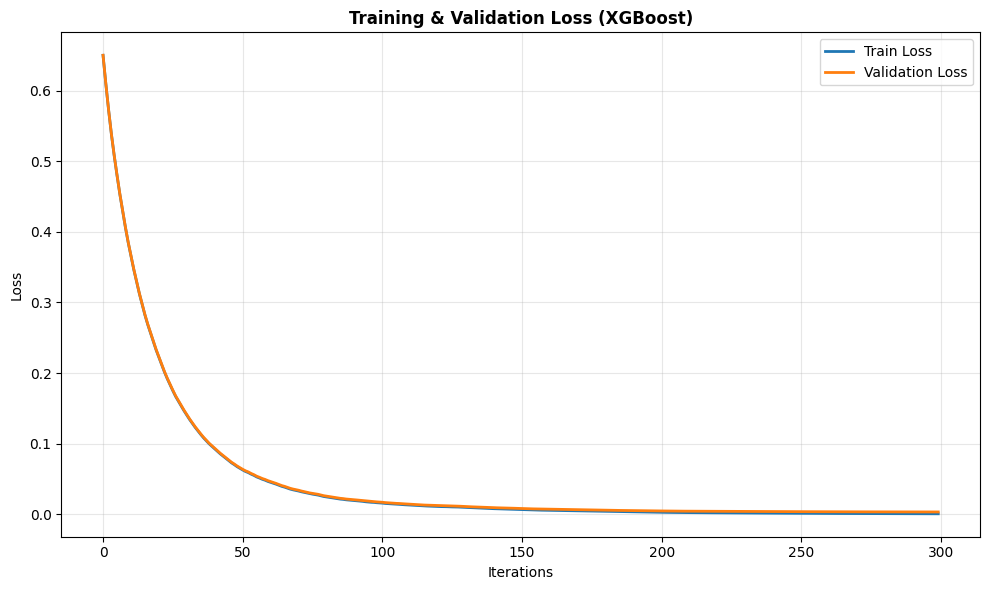

In [46]:
results = model.evals_result()

plt.figure(figsize=(10, 6))

plt.plot(results['validation_0']['logloss'], label='Train Loss', linewidth=2)
plt.plot(results['validation_1']['logloss'], label='Validation Loss', linewidth=2)

plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.title("Training & Validation Loss (XGBoost)", fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

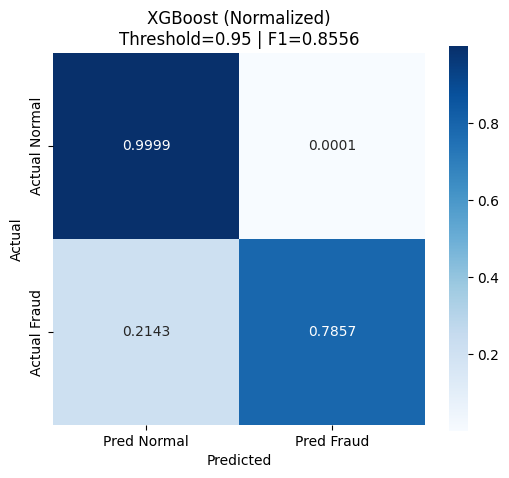

In [47]:
cm = test_metrics["confusion_matrix"]
cm_norm = cm.astype(float) / cm.sum(axis=1)[:, None]

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_norm,
    annot=True,
    fmt='.4f',
    cmap='Blues',
    xticklabels=['Pred Normal', 'Pred Fraud'],
    yticklabels=['Actual Normal', 'Actual Fraud'],
    square=True
)

plt.title(f'XGBoost (Normalized)\nThreshold={best_threshold:.2f} | F1={test_metrics["f1"]:.4f}')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Analysis of results 
_(Comparison: XGBoost Model vs Weighted Classifier)_

## Confusion Matrix Comparison

<p align="center">
  <img src="images/xgboost_cm.png" width="45%">
  <img src="images/weighted_cm.png" width="45%">
</p>

## Key Metrics Comparison

| Metric            | XGBoost    | Weighted NN | Better            |
| ----------------- | ---------- | ----------- | ----------------- |
| Accuracy          | 0.9995     | 0.9993      | XGBoost           |
| Balanced Accuracy | 0.8928     | **0.9131**  | Weighted          |
| Precision         | **0.9390** | 0.7941      | XGBoost           |
| Recall            | 0.7857     | **0.8265**  | Weighted          |
| F1 Score          | **0.8556** | 0.8100      | XGBoost           |
| ROC-AUC           | 0.9771     | **0.9795**  | Weighted (slight) |
| PR-AUC            | **0.8697** | 0.7387      | XGBoost           |


- The XGBoost model outperformed the weighted neural network in terms of overall performance, achieving a higher F1 score (0.8556 vs 0.8100) and significantly higher precision (0.9390 vs 0.7941). 
- This indicates that XGBoost is more effective at correctly identifying fraudulent transactions while minimizing false positives.

- Although the weighted classifier achieved slightly higher recall (0.8265 vs 0.7857), meaning it detected more fraud cases, it did so at the cost of a higher false positive rate. 
- This trade-off is reflected in the confusion matrix, where the weighted model produced 21 false positives compared to only 5 in XGBoost.

- Additionally, XGBoost achieved a substantially higher PR-AUC (0.8697 vs 0.7387), which is a more reliable metric for imbalanced datasets such as fraud detection. This suggests that XGBoost provides a better balance between precision and recall across different thresholds.

Overall, XGBoost demonstrates superior performance for this task and is more suitable for real-world deployment, where minimizing false alarms while maintaining strong fraud detection capability is critical.